# Objective :Prepare the data for modeling
## First objective is to prepare the data for modeling by selecting a subset of fields, making sure they are numeric, looking at their distributions, and engineering a new feature

### Task : Segment the current customers and recommend potential new products and services for each segment

### Read the "Bank_Churn.csv" file and preview the top 5 rows

In [1]:
import pandas as pd 
cust_churn = pd.read_csv('Bank_Churn.csv')

cust_churn.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Create a DataFrame containing all fields except "CustomerId", "Surname" and "Exited"

In [2]:
cust_churn_updated = cust_churn.drop(["CustomerId", "Surname", "Exited"],axis=1)

cust_churn_updated.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


### Make all text fields numeric

In [3]:
cust_churn_updated.dtypes

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
dtype: object

In [4]:
cust_churn_clean = cust_churn_updated.copy()

cust_churn_clean.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [5]:
cust_churn_clean.Gender.value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [6]:
import numpy as np

cust_churn_clean.Gender = np.where(cust_churn_clean.Gender == 'Female',1,0)

cust_churn_clean.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,1,42,2,0.00,1,1,1,101348.88
1,608,Spain,1,41,1,83807.86,1,0,1,112542.58
2,502,France,1,42,8,159660.80,3,1,0,113931.57
3,699,France,1,39,1,0.00,2,0,0,93826.63
4,850,Spain,1,43,2,125510.82,1,1,1,79084.10


In [7]:
cust_churn_clean.Geography.value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [8]:
cust_churn_clean = pd.get_dummies(cust_churn_clean, columns = ["Geography"],dtype = "int",prefix ='',prefix_sep='')

### Explore the data by looking at the min/max values and the distribution of each column

In [9]:
cust_churn_clean.describe()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,0.454300,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.501400,0.250900,0.247700
std,96.653299,0.497932,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.500023,0.433553,0.431698
min,350.000000,0.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,0.000000
25%,584.000000,0.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,0.000000
50%,652.000000,0.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,1.000000,0.000000,0.000000
75%,718.000000,1.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,1.000000,1.000000,0.000000
max,850.000000,1.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,1.000000


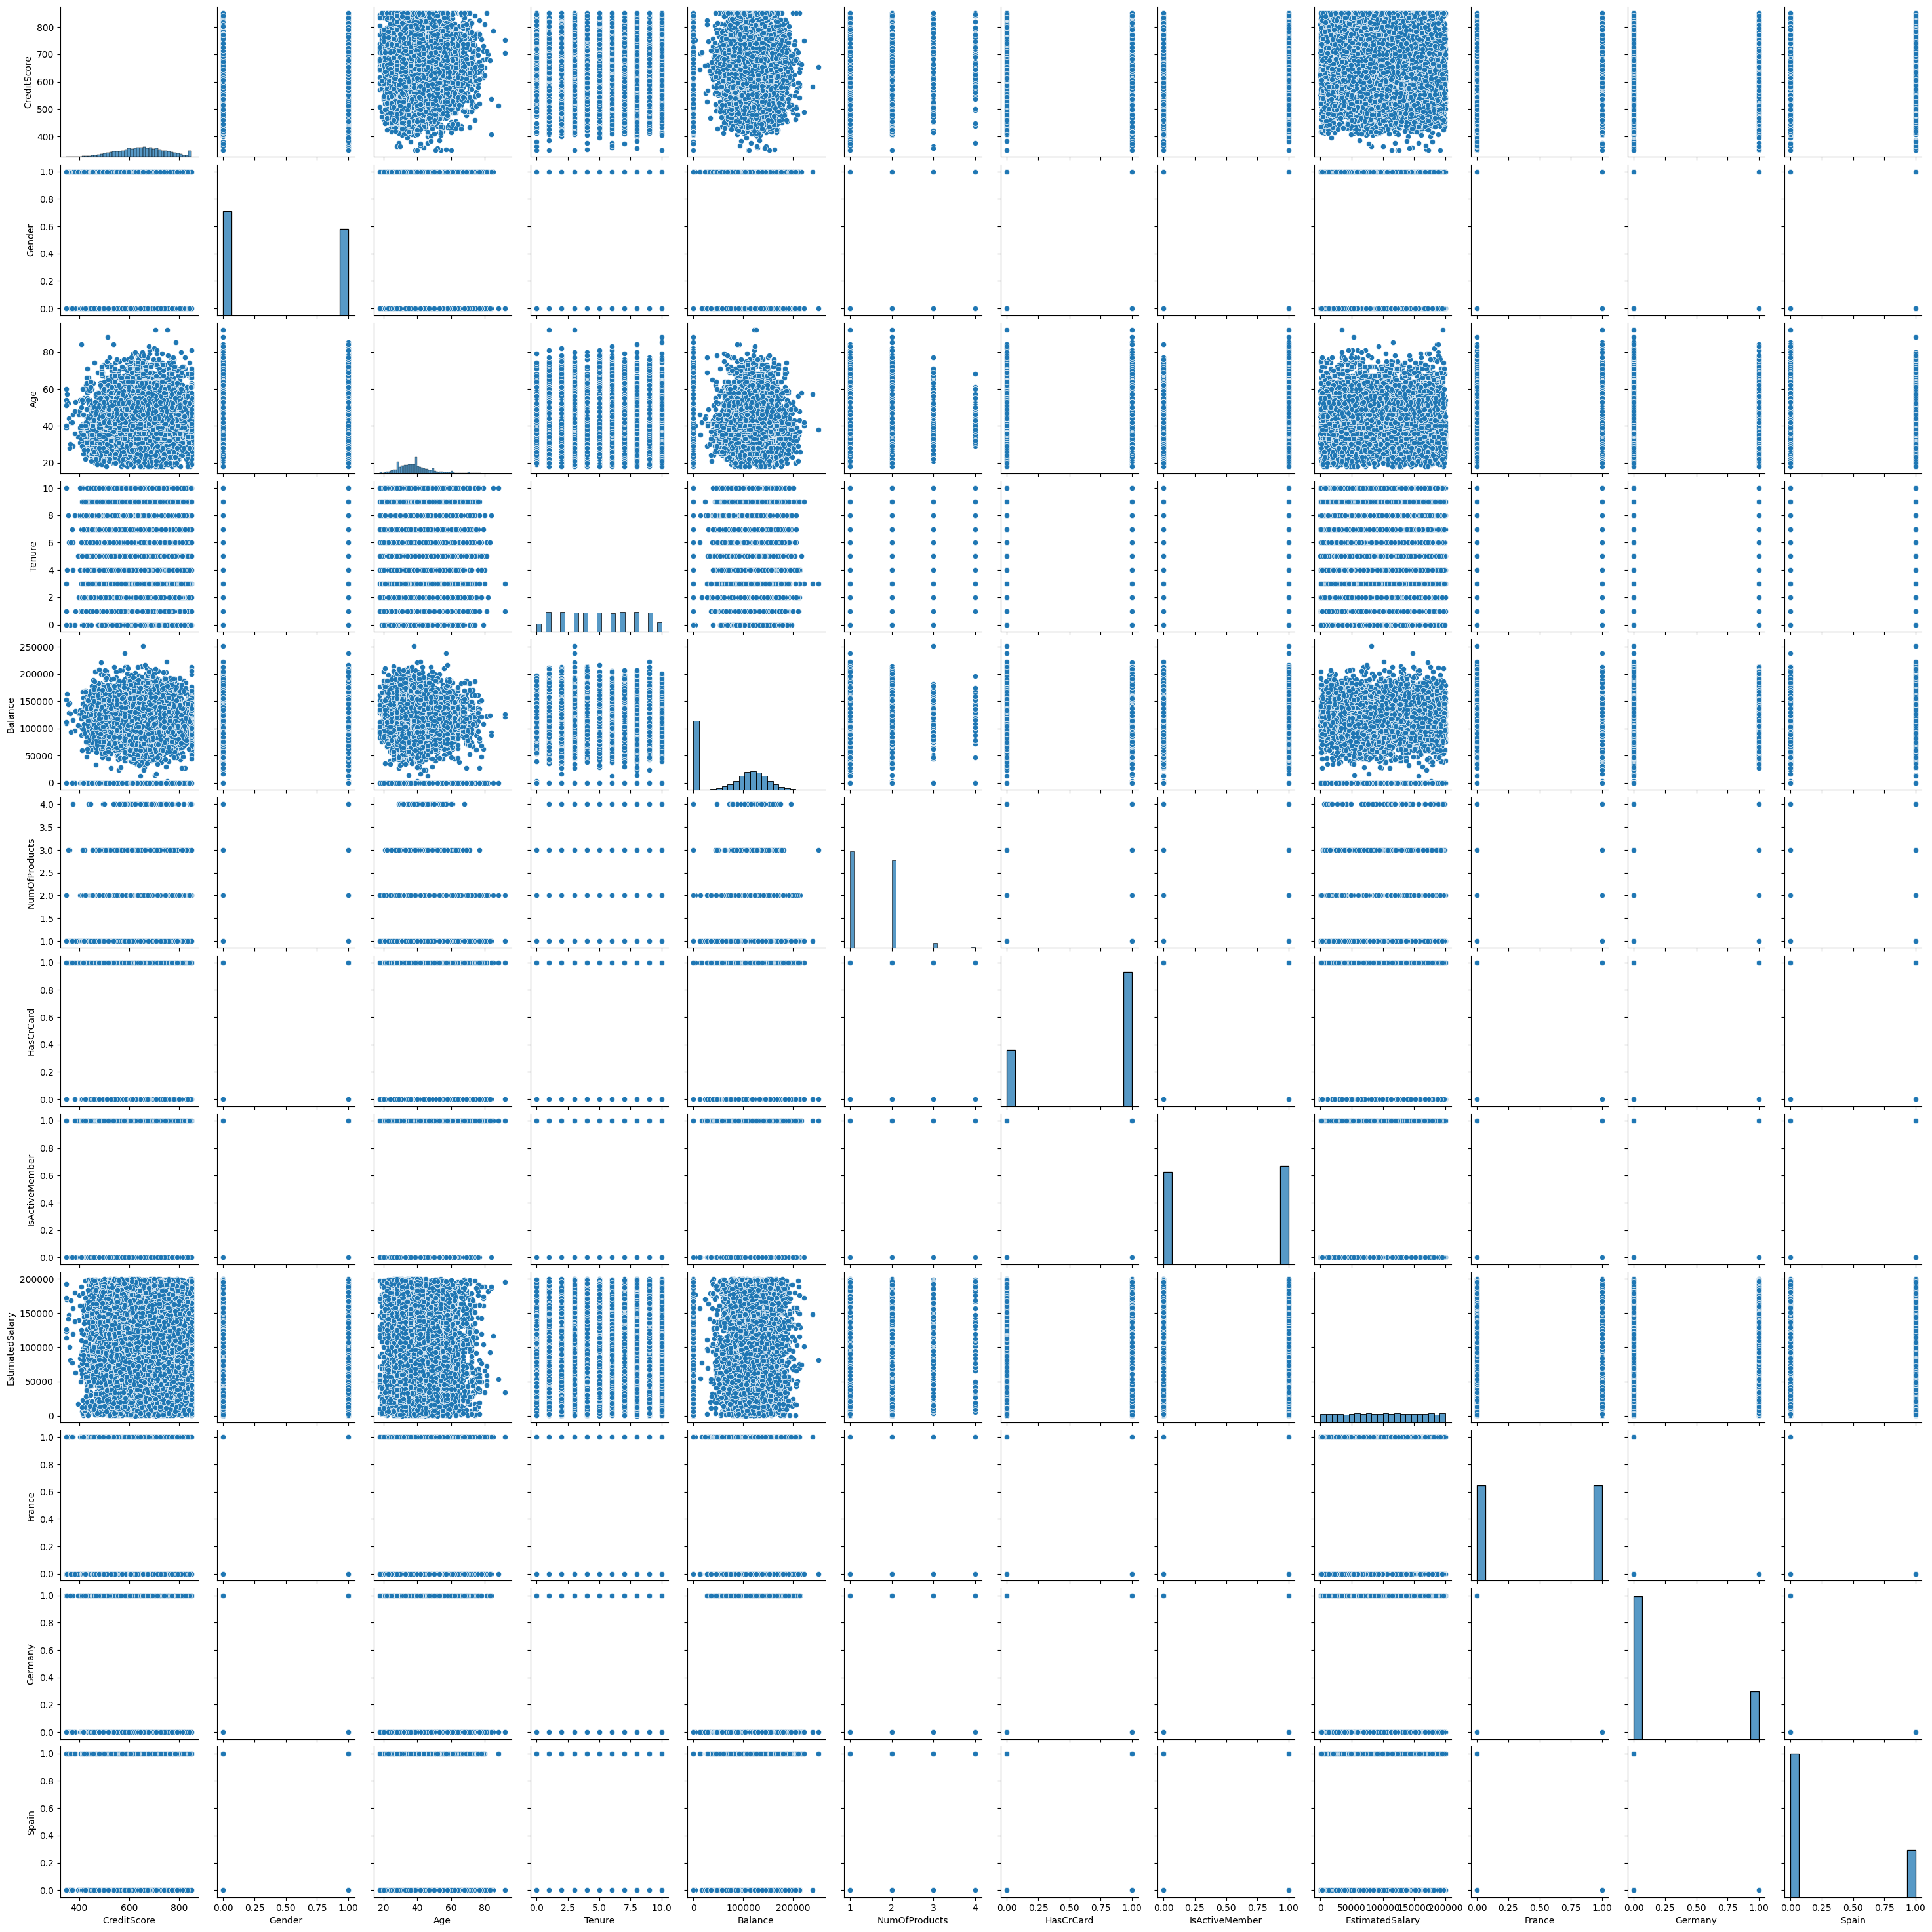

In [10]:
import seaborn as sns

sns.pairplot(cust_churn_clean)

### Engineer a new feature called "ProductsPerYear"

In [11]:
#cust_churn_clean["ProductsPerYear"] = cust_churn_clean.NumOfProducts/cust_churn_clean.Tenure

cust_churn_clean["ProductsPerYear"] = np.where(cust_churn_clean.Tenure == 0 ,cust_churn_clean.NumOfProducts,cust_churn_clean.NumOfProducts/cust_churn_clean.Tenure) 
cust_churn_clean.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain,ProductsPerYear
0,619,1,42,2,0.00,1,1,1,101348.88,1,0,0,0.500
1,608,1,41,1,83807.86,1,0,1,112542.58,0,0,1,1.000
2,502,1,42,8,159660.80,3,1,0,113931.57,1,0,0,0.375
3,699,1,39,1,0.00,2,0,0,93826.63,1,0,0,2.000
4,850,1,43,2,125510.82,1,1,1,79084.10,0,0,1,0.500


In [12]:
cust_churn_clean.describe()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain,ProductsPerYear
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,0.454300,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.501400,0.250900,0.247700,0.508523
std,96.653299,0.497932,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.500023,0.433553,0.431698,0.507921
min,350.000000,0.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,0.000000,0.100000
25%,584.000000,0.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,0.000000,0.200000
50%,652.000000,0.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,1.000000,0.000000,0.000000,0.333333
75%,718.000000,1.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,1.000000,1.000000,0.000000,0.666667
max,850.000000,1.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,1.000000,4.000000


# Objective 2 : Cluster the customers (round 1)
## Second objective is to segment the customers using K-Means clustering, including standardizing the data, creating an inertia plot, and interpreting the clusters.

### Standardize the data so that each column has a mean of 0 and standard deviation of 1

In [13]:
cust_churn_clean.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain,ProductsPerYear
0,619,1,42,2,0.00,1,1,1,101348.88,1,0,0,0.500
1,608,1,41,1,83807.86,1,0,1,112542.58,0,0,1,1.000
2,502,1,42,8,159660.80,3,1,0,113931.57,1,0,0,0.375
3,699,1,39,1,0.00,2,0,0,93826.63,1,0,0,2.000
4,850,1,43,2,125510.82,1,1,1,79084.10,0,0,1,0.500


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cust_churn_scaled = pd.DataFrame(scaler.fit_transform(cust_churn_clean), columns=cust_churn_clean.columns)

cust_churn_scaled.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain,ProductsPerYear
0,-0.326221,1.095988,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886,0.997204,-0.578736,-0.573809,-0.016781
1,-0.440036,1.095988,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,-1.002804,-0.578736,1.742740,0.967674
2,-1.536794,1.095988,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,0.997204,-0.578736,-0.573809,-0.262894
3,0.501521,1.095988,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918,0.997204,-0.578736,-0.573809,2.936584
4,2.063884,1.095988,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276,-1.002804,-0.578736,1.742740,-0.016781


In [15]:
cust_churn_scaled.describe()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain,ProductsPerYear
count,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04
mean,-4.824585e-16,-2.131628e-18,2.318146e-16,-1.078249e-16,-6.252776e-17,1.634248e-17,-5.258016e-17,-7.389644e-17,-2.877698e-17,2.096101e-17,-7.069900e-17,-4.689582e-17,1.957545e-16
std,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00
min,-3.109504e+00,-9.124191e-01,-1.994969e+00,-1.733315e+00,-1.225848e+00,-9.115835e-01,-1.547768e+00,-1.030670e+00,-1.740268e+00,-1.002804e+00,-5.787359e-01,-5.738092e-01,-8.043445e-01
25%,-6.883586e-01,-9.124191e-01,-6.600185e-01,-6.959818e-01,-1.225848e+00,-9.115835e-01,-1.547768e+00,-1.030670e+00,-8.535935e-01,-1.002804e+00,-5.787359e-01,-5.738092e-01,-6.074535e-01
50%,1.522218e-02,-9.124191e-01,-1.832505e-01,-4.425957e-03,3.319639e-01,-9.115835e-01,6.460917e-01,9.702426e-01,1.802807e-03,9.972039e-01,-5.787359e-01,-5.738092e-01,-3.449322e-01
75%,6.981094e-01,1.095988e+00,4.842246e-01,6.871299e-01,8.199205e-01,8.077366e-01,6.460917e-01,9.702426e-01,8.572431e-01,9.972039e-01,1.727904e+00,-5.738092e-01,3.113709e-01
max,2.063884e+00,1.095988e+00,5.061197e+00,1.724464e+00,2.795323e+00,4.246377e+00,6.460917e-01,9.702426e-01,1.737200e+00,9.972039e-01,1.727904e+00,1.742740e+00,6.874403e+00


### Fit K-Means Clustering models on the standardized data with 2-15 clusters to create an inertia plot

In [16]:
# import kmeans and write a loop to fit models with 2 to 15 clusters
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# create an empty list to hold more inertia and silhouette values

inertia_values = []
silhouette_scores = []

# create 2 - 15 clusters, and add the inertia and silhouette values to the list

for k in range(2,16):
    kmeans= KMeans(n_clusters=k,n_init=10,random_state=42)
    kmeans.fit(cust_churn_scaled)
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(cust_churn_scaled,kmeans.labels_,metric='euclidean',sample_size=None))

Text(0.5, 1.0, 'Number of clusers Vs Inertia')

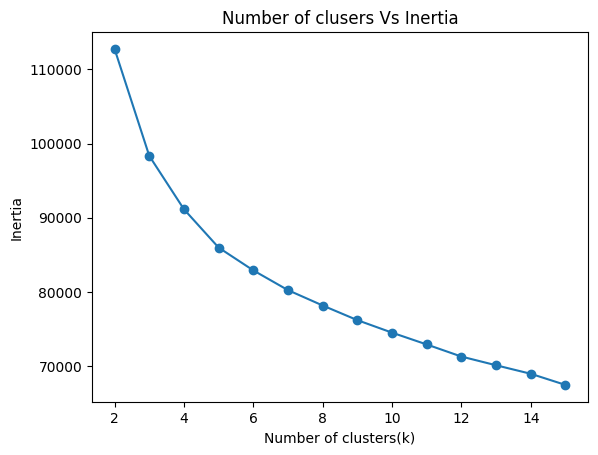

In [17]:
# plot the inertia values

import matplotlib.pyplot as plt

# turn the list into a series of plotting
inertia_series = pd.Series(inertia_values, index=range(2,16))

#plot the data
inertia_series.plot(marker='o')
plt.xlabel("Number of clusters(k)")
plt.ylabel("Inertia")
plt.title("Number of clusers Vs Inertia")


### Identify the elbow of the inertia plot and fit a K-Means model using that value of k

In [18]:
kmeans5 = KMeans(n_clusters=5, n_init=10, random_state=42)

kmeans5.fit(cust_churn_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


### Check the number of customers in each cluster

In [19]:
from collections import Counter

Counter(kmeans5.labels_)


Counter({np.int32(3): 2343,
         np.int32(2): 2336,
         np.int32(4): 2329,
         np.int32(1): 2305,
         np.int32(0): 687})

### Create a heat map of cluster centers and interpret the clusters

<Axes: >

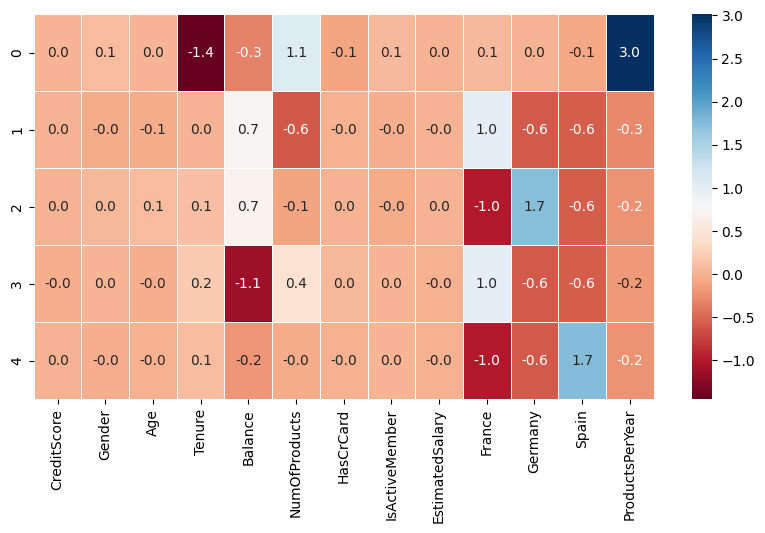

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

cluster_centers5 = pd.DataFrame(kmeans5.cluster_centers_, columns = cust_churn_scaled.columns)

plt.figure(figsize= (10,5))
sns.heatmap(cluster_centers5, annot=True,cmap = "RdBu",fmt=".1f",linewidths=0.5)

* 0: Many Products for a shorttime
* 1: French Customers with high balance
* 2: German Customers with high balance
* 3: French Customers with low balance
* 4: Spanish Customers

# Objective 3:Cluster the customers (round 2)
## Third objective is to segment the customers using K-Means clustering using a different subset of fields and compare the model results.

In [22]:
cust_churn_updated.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [23]:
cust_churn_geo = cust_churn_updated.copy()

In [24]:
cust_churn_geo.Gender = np.where(cust_churn_geo.Gender=='Female',1,0)
cust_churn_geo.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,1,42,2,0.00,1,1,1,101348.88
1,608,Spain,1,41,1,83807.86,1,0,1,112542.58
2,502,France,1,42,8,159660.80,3,1,0,113931.57
3,699,France,1,39,1,0.00,2,0,0,93826.63
4,850,Spain,1,43,2,125510.82,1,1,1,79084.10


### Take a look at the summary stats by country and exclude the country fields

In [25]:
cust_churn_geo.groupby('Geography').mean()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
Geography,,,,,,,,,
France,649.668329,0.450937,38.511767,5.004587,62092.636516,1.530913,0.706621,0.516753,99899.180814
Germany,651.453567,0.475488,39.771622,5.009964,119730.116134,1.519729,0.713830,0.497409,101113.435102
Spain,651.333872,0.439645,38.890997,5.032297,61818.147763,1.539362,0.694792,0.529673,99440.572281


In [27]:
cust_churn_geo[cust_churn_geo.Geography == 'France'].Balance.round(-5).value_counts()

Balance
0.0         2459
100000.0    2123
200000.0     432
Name: count, dtype: int64

In [28]:
cust_churn_geo[cust_churn_geo.Geography == 'Germany'].Balance.round(-5).value_counts()

Balance
100000.0    2176
200000.0     314
0.0           19
Name: count, dtype: int64

In [29]:
cust_churn_geo[cust_churn_geo.Geography == 'Spain'].Balance.round(-5).value_counts()

Balance
0.0         1214
100000.0    1040
200000.0     222
300000.0       1
Name: count, dtype: int64

In [31]:
cust_churn_scaled_nogeo = cust_churn_scaled.drop(columns = ['France','Germany','Spain'])
cust_churn_scaled_nogeo.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,ProductsPerYear
0,-0.326221,1.095988,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886,-0.016781
1,-0.440036,1.095988,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,0.967674
2,-1.536794,1.095988,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,-0.262894
3,0.501521,1.095988,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918,2.936584
4,2.063884,1.095988,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276,-0.016781


### Fit K-Means Clustering models on the standardized data without country fields with 2-15 clusters to create an inertia plot

In [33]:
# import kmeans and write a loop to fit models with 2 to 15 clusters
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# create an empty list to hold more inertia and silhouette values

inertia_values = []
silhouette_scores = []

# create 2 - 15 clusters, and add the inertia and silhouette values to the list

for k in range(2,16):
    kmeans= KMeans(n_clusters=k,n_init=10,random_state=42)
    kmeans.fit(cust_churn_scaled_nogeo)
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(cust_churn_scaled_nogeo,kmeans.labels_,metric='euclidean',sample_size=None))

Text(0.5, 1.0, 'Number of clusers Vs Inertia')

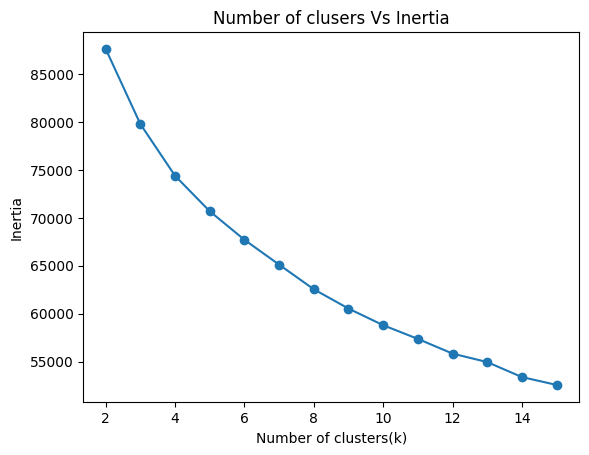

In [34]:
# plot the inertia values

import matplotlib.pyplot as plt

# turn the list into a series of plotting
inertia_series = pd.Series(inertia_values, index=range(2,16))

#plot the data
inertia_series.plot(marker='o')
plt.xlabel("Number of clusters(k)")
plt.ylabel("Inertia")
plt.title("Number of clusers Vs Inertia")


### Identify the elbow of the inertia plot and fit a K-Means model using that value of k

In [35]:
kmeans4 = KMeans(n_clusters=4, n_init=10, random_state=42)

kmeans4.fit(cust_churn_scaled_nogeo)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


### Check the number of customers in each cluster

In [36]:
Counter(kmeans4.labels_)

Counter({np.int32(1): 3223,
         np.int32(2): 2366,
         np.int32(0): 2276,
         np.int32(3): 2135})

### Create a heat map of cluster centers and interpret the clusters

<Axes: >

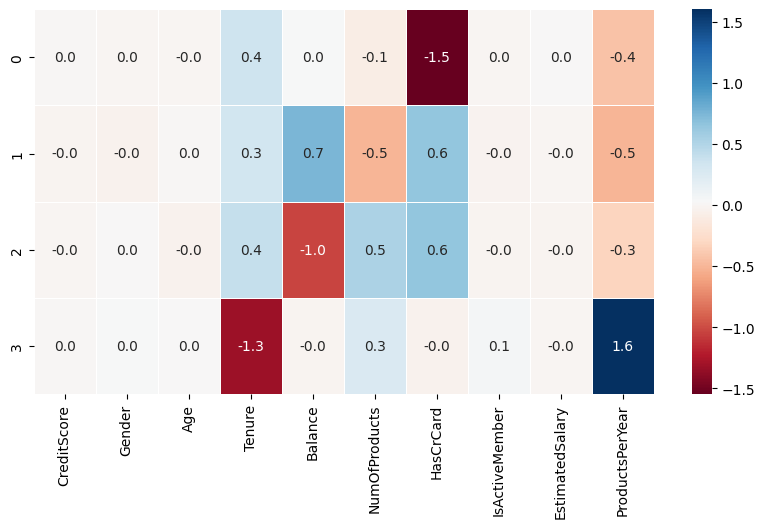

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

cluster_centers4 = pd.DataFrame(kmeans4.cluster_centers_, columns = cust_churn_scaled_nogeo.columns)

plt.figure(figsize= (10,5))
sns.heatmap(cluster_centers4, annot=True,cmap = "RdBu",fmt=".1f",linewidths=0.5)

* 0 : Who don't have a credit card
* 1 : Who has high balance, few products and has a credit card
* 2 : Who has low balance, more products and has credit card 
* 3 : Who has many products in short amount of time
    

# Objective 4 : Explore the clusters and make recommendations
## Your final objective is to further explore your K-Means clusters by looking at their churn rate and country breakdown, then make recommendations for how to cater to each one.

### * Create a DataFrame that combines the data set from the end of Objective 1
### * the "Exited" field
### * the cluster labels

In [38]:
cust_churn_clean.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain,ProductsPerYear
0,619,1,42,2,0.00,1,1,1,101348.88,1,0,0,0.500
1,608,1,41,1,83807.86,1,0,1,112542.58,0,0,1,1.000
2,502,1,42,8,159660.80,3,1,0,113931.57,1,0,0,0.375
3,699,1,39,1,0.00,2,0,0,93826.63,1,0,0,2.000
4,850,1,43,2,125510.82,1,1,1,79084.10,0,0,1,0.500


In [39]:
cust_churn.Exited.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [40]:
kmeans4.labels_

array([2, 3, 2, ..., 0, 2, 1], dtype=int32)

In [43]:
cust_churn_final = pd.concat([cust_churn_clean,cust_churn.Exited,pd.Series(kmeans4.labels_,name='Cluster')],axis=1)

cust_churn_final.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain,ProductsPerYear,Exited,Cluster
0,619,1,42,2,0.00,1,1,1,101348.88,1,0,0,0.500,1,2
1,608,1,41,1,83807.86,1,0,1,112542.58,0,0,1,1.000,0,3
2,502,1,42,8,159660.80,3,1,0,113931.57,1,0,0,0.375,1,2
3,699,1,39,1,0.00,2,0,0,93826.63,1,0,0,2.000,0,3
4,850,1,43,2,125510.82,1,1,1,79084.10,0,0,1,0.500,0,1


### View the churn rate (% of customers who "Exited") for each cluster

In [44]:
cust_churn_final.groupby('Cluster').mean()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain,ProductsPerYear,Exited
Cluster,,,,,,,,,,,,,,
0,651.201230,0.455624,38.917838,6.033392,78730.204165,1.480228,0.000000,0.515378,101285.720879,0.500439,0.240334,0.259227,0.286305,0.209578
1,649.375427,0.434068,39.043438,5.981074,123236.381930,1.237357,1.000000,0.499224,99856.400177,0.423829,0.378219,0.197952,0.248201,0.226807
2,650.235418,0.462806,38.515216,6.167794,11731.060702,1.833052,0.999155,0.508453,99487.179958,0.622570,0.066357,0.311074,0.341581,0.164835
3,651.878220,0.474005,39.192974,1.183138,75279.812468,1.689930,0.687588,0.546136,99837.120628,0.485246,0.274473,0.240281,1.323404,0.205621


### View the country breakdown for each cluster

From the data above it can be seen that there are lots of French Customers for Cluster 2 customers , which stands out

### Make recommendations for how to cater to each customer segment

* 0 : Who don't have a credit card
* 1 : Who has high balance, few products and has a credit card
* 2 : Who has low balance, more products and has credit card 
* 3 : Who has many products in short amount of time

# Recommendations

# 0 : Create an entry level credit Card
# 1 : Financial Advisor , more investment opportunities , entice high balance customers to stay
# 2 : Reward them for high tenure to French and Spanish Customers
# 3 : Pitch in more products for higher tenure thus encourage them to stay